![NVIDIA Logo](images/nvidia.png)

# Broadcast Nodes

In this notebook we introduce the MRC node `Broadcast` which can be used inside of custom stages to create nodes capable of broadcasting its results over multiple edges to multiple down stream nodes.

---

## Objectives

By the time you complete this notebook you will be able to:

- Create `Broadcast` nodes inside of custom stages.
- Create custom stages capable of sending results over multiple ouput ports.

---

## Imports

In [1]:
import logging
import typing

from IPython.display import Image

from morpheus.config import Config

from morpheus.pipeline import Pipeline
from morpheus.pipeline.execution_mode_mixins import GpuAndCpuMixin
from morpheus.pipeline.pass_thru_type_mixin import PassThruTypeMixin
from morpheus.pipeline.single_port_stage import SinglePortStage

from morpheus.pipeline.stage import Stage
from morpheus.pipeline.stage_schema import StageSchema

from morpheus.stages.general.monitor_stage import MonitorStage
from morpheus.stages.input.file_source_stage import FileSourceStage
from morpheus.stages.output.in_memory_sink_stage import InMemorySinkStage

from morpheus.messages import MessageMeta

from morpheus.utils.logger import configure_logging, reset_logging

import mrc
import mrc.core.operators as ops
from mrc.core.node import Broadcast

---

## Broadcast Nodes

So far, in the service of creating non-linear pipelines with stages capable of sending and/or receiving to and from multiple  other stages, we have explored how to explicitly define the number of incoming and outgoing ports in a stage, and have also looked at how to create an arbitrary number of nodes connected via edges inside of a custom stage.

As a next step before finally being able to actually create non-linear pipelines, we look at how to create **broadcast** nodes using `mrc.core.node.Broadcast`.

`Broadcast` is able to receive inputs from a single node and then send results over multiple nodes.

To begin we will yet again create a simple passthrough custom stage, but this time instead of creating the stage's inner node with `builder.make_node`, we will create a node using `Broadcast`.

In [2]:
class BroadcastStage(GpuAndCpuMixin, PassThruTypeMixin, Stage):

    def __init__(self, c: Config):
        super().__init__(c)

        self._create_ports(1, 1) # One input port, one output port

    @property
    def name(self) -> str:
        return "bcast"

    def supports_cpp_node(self):
        return False
    
    def on_data(self, message: MessageMeta) -> MessageMeta:
        return message

    def _build(self, builder: mrc.Builder, input_nodes: list[mrc.SegmentObject]) -> list[mrc.SegmentObject]:

        # Here we create a node using `Broadcast`.
        broadcast = Broadcast(builder, "broadcast")
        builder.make_edge(input_nodes[0], broadcast)

        # For now, our broadcast node is only connecting via edge to a single node.
        outgoing = builder.make_node("outgoing", ops.map(self.on_data))
        builder.make_edge(broadcast, outgoing)

        return [outgoing]

Just to confirm everything works as expected, here we build and run our pipeline.

In [3]:
input_file = 'data/simple_user_log.jsonlines'

config = Config()

pipeline = Pipeline(config)

source = pipeline.add_stage(FileSourceStage(config, filename=input_file, iterative=False, repeat=100))
broadcast = pipeline.add_stage(BroadcastStage(config))
in_mem_sink = pipeline.add_stage(InMemorySinkStage(config))
monitor = pipeline.add_stage(MonitorStage(config, description="Pipeline throughput"))

pipeline.add_edge(source, broadcast)
pipeline.add_edge(broadcast, in_mem_sink)
pipeline.add_edge(in_mem_sink, monitor)

In [4]:
pipeline.build()

In [5]:
viz_file = './pipeline_visualizations/mp_passthrough.png'
pipeline.visualize(viz_file)

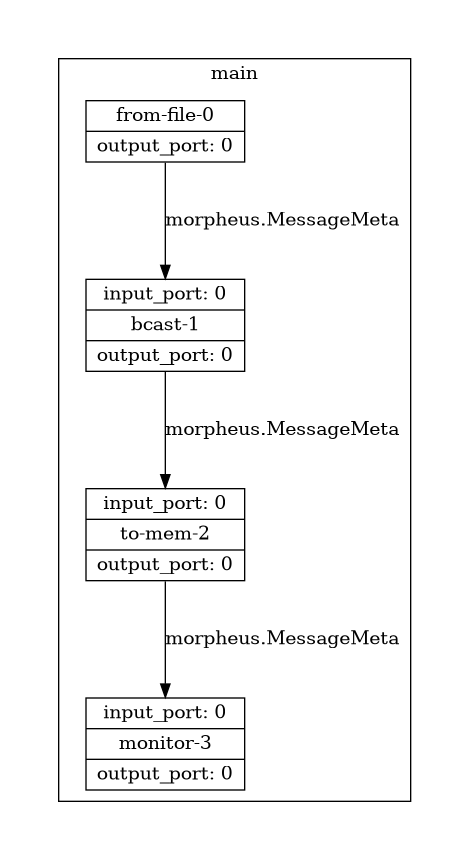

In [6]:
Image(filename=viz_file)

In [7]:
reset_logging()
configure_logging(log_level=logging.DEBUG)

====Starting Pipeline====
====Pipeline Started====
====Building Segment: main====
Added source: <from-file-0; FileSourceStage(filename=data/simple_user_log.jsonlines, iterative=False, file_type=FileTypes.Auto, repeat=100, filter_null=True, filter_null_columns=None, parser_kwargs=None)>
  └─> morpheus.MessageMeta


Added stage: <to-mem-2; InMemorySinkStage()>
  └─ morpheus.MessageMeta -> morpheus.MessageMeta


Added stage: <monitor-3; MonitorStage(description=Pipeline throughput, smoothing=0.05, unit=messages, delayed_start=False, determine_count_fn=None, log_level=LogLevels.INFO)>
  └─ morpheus.MessageMeta -> morpheus.MessageMeta


====Building Segment Complete!====


Pipeline throughput: 0 messages [00:00, ? messages/s]

====Pipeline Complete====
====Pipeline Pre-build====
====Pre-Building Segment: main====
====Pre-Building Segment Complete!====
====Pipeline Pre-build Complete!====
====Registering Pipeline====
====Building Pipeline====
====Building Pipeline Complete!====
====Registering Pipeline Complete!====


In [8]:
await pipeline.run_async()

Pipeline throughput[Complete]: 1000 messages [00:02, 479.91 messages/s]


In [9]:
messages = in_mem_sink.get_messages()
messages[0].get_data()

,timestamp,user,ip_address,request_time,status,error_message
0,2025-02-01T10:15:30Z,user123,192.168.1.10,200.45,success,<NA>
1,2025-02-01T10:17:00Z,user123,192.168.1.20,150.55,failure,Invalid credentials
2,2025-02-01T10:18:10Z,user456,10.0.0.5,180.60,success,<NA>
3,2025-02-01T10:19:25Z,user789,192.168.1.30,215.25,failure,Timeout
4,2025-02-01T10:20:00Z,user456,10.0.0.6,120.10,success,<NA>
5,2025-02-01T10:22:30Z,user123,192.168.1.40,175.35,failure,Access denied
6,2025-02-01T10:23:45Z,user321,192.168.1.50,205.50,success,<NA>
7,2025-02-01T10:25:05Z,user864,192.168.1.60,190.15,failure,Invalid session
8,2025-02-01T10:26:20Z,user123,192.168.1.70,210.80,success,<NA>
9,2025-02-01T10:27:40Z,user456,10.0.0.7,160.95,failure,Account locked


---

## Broadcasting to Multiple Nodes

Now let's create a custom stage that utilizes `Broadcast` as intended, sending results to multiple downstream nodes.

We have to make several modifications to our stage definition compared to `BroadcastStage` above. Please read the comments in the following definition of a multiple-output port broadcast stage.

In [10]:
# We are no longer going to be receiving and sending the same message types and number of messages.
# Therefore, we can no longer utilize the `PassThruTypeMixin`.
class MpBroadcastStage(GpuAndCpuMixin, Stage):

    def __init__(self, c: Config):
        super().__init__(c)

        # Here we define that this stage will have two output ports.
        self._create_ports(1, 3) # One input port, two output ports.

    @property
    def name(self) -> str:
        return "mp-bcast"

    def supports_cpp_node(self):
        return False
    
    # In previous custom stages, `PassThruTypeMixin` was defining the `compute_schema` method for us,
    # but now we need to define it explicitly.
    
    # compute_schema will receive a `StageSchema` argument, whose `output_schemas` property will
    # contain details about all defined output ports. For each output port (in our case 2), we need
    # to specify via the `set_type` method, the type of the output.
    # Here we specify `typing.Any` but this may very well be `MessageMeta` or `ControlMessage` in other settings.
    def compute_schema(self, schema: StageSchema):
        for port_schema in schema.output_schemas:
            port_schema.set_type(typing.Any)
    
    def on_data(self, message: typing.Any) -> typing.Any:
        return message

    def _build(self, builder: mrc.Builder, input_nodes: list[mrc.SegmentObject]) -> list[mrc.SegmentObject]:

        # Create a broadcast node
        broadcast = Broadcast(builder, "broadcast")
        builder.make_edge(input_nodes[0], broadcast)

        # Here we create 2 outgoing nodes.
        outgoing_1 = builder.make_node("outgoing_1", ops.map(self.on_data))
        outgoing_2 = builder.make_node("outgoing_2", ops.map(self.on_data))
        outgoing_3 = builder.make_node("outgoing_3", ops.map(self.on_data))
        
        # Here we create edges between the broadcast node and each of the outgoing nodes.
        builder.make_edge(broadcast, outgoing_1)
        builder.make_edge(broadcast, outgoing_2)
 
        # Here we return both outgoing nodes.
        return [outgoing_1, outgoing_2]

---

## Build and Run a Broadcasting Pipeline

We'll start per usual by defining our source stage, and will also define a stage using our custom `MpBroadcastStage` we just defined. We'll then connect the source stage to the broadcast stage via an edge.

In [11]:
input_file = 'data/simple_user_log.jsonlines'

config = Config()
pipeline = Pipeline(config)

source = pipeline.add_stage(FileSourceStage(config, filename=input_file, iterative=False))
broadcast = pipeline.add_stage(MpBroadcastStage(config))

pipeline.add_edge(source, broadcast)

Since we intend to broadcast to over 2 ports, we'll create 2 in memory sink stages.

In [12]:
in_mem_sink_1 = pipeline.add_stage(InMemorySinkStage(config))
in_mem_sink_2 = pipeline.add_stage(InMemorySinkStage(config))
in_mem_sink_3 = pipeline.add_stage(InMemorySinkStage(config))

And now create two new edges from the broadcast stage, one to each of our in memory sinks.

Node when a stage emits messages over multiple ports, we need to specify in edge creation which port by using the stage's `output_ports` property and indexing into appropriately for the desired output port.

In [13]:
pipeline.add_edge(broadcast.output_ports[0], in_mem_sink_1)
pipeline.add_edge(broadcast.output_ports[1], in_mem_sink_2)
pipeline.add_edge(broadcast.output_ports[2], in_mem_sink_3)

Having created the pipeline let's now build it.

In [14]:
pipeline.build()

Looking at the pipeline's visualization we get to observe how `mp-bcast` has multiple output ports and how they are connected to multiple output stages.

In [15]:
viz_file = './pipeline_visualizations/mp_passthrough.png'
pipeline.visualize(viz_file)

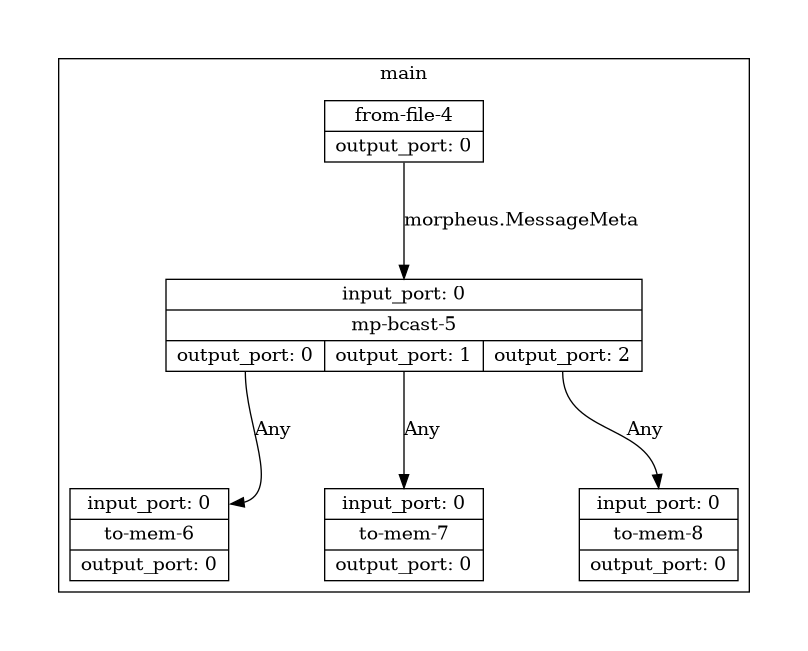

In [16]:
Image(filename=viz_file)

Now let's run the pipeline.

In [17]:
reset_logging()
configure_logging(log_level=logging.DEBUG)

W20250923 08:24:02.215488 140147977942848 logging.cpp:67] MRC logger already initialized


====Starting Pipeline====
====Pipeline Started====
====Building Segment: main====
Added source: <from-file-4; FileSourceStage(filename=data/simple_user_log.jsonlines, iterative=False, file_type=FileTypes.Auto, repeat=1, filter_null=True, filter_null_columns=None, parser_kwargs=None)>
  └─> morpheus.MessageMeta


Exception occurred in pipeline. Rethrowing
Traceback (most recent call last):
  File "/opt/conda/envs/morpheus/lib/python3.10/site-packages/morpheus/pipeline/pipeline.py", line 408, in post_start
    await executor.join_async()
  File "/opt/conda/envs/morpheus/lib/python3.10/site-packages/morpheus/pipeline/pipeline.py", line 320, in inner_build
    stage.build(builder)
  File "/opt/conda/envs/morpheus/lib/python3.10/site-packages/morpheus/pipeline/stage_base.py", line 438, in build
    dep.build(builder, do_propagate=do_propagate)
  File "/opt/conda/envs/morpheus/lib/python3.10/site-packages/morpheus/pipeline/stage_base.py", line 421, in build
    assert len(out_ports_nodes) == len(self.output_ports), \
AssertionError: Build must return same number of output pairs as output ports


====Pipeline Complete====


In [18]:
await pipeline.run_async()

E20250923 08:24:02.222333 140142579091008 builder_definition.cpp:318] Exception during segment initializer. Segment name: main, Segment Rank: 0. Exception message:
AssertionError: Build must return same number of output pairs as output ports

At:
  /opt/conda/envs/morpheus/lib/python3.10/site-packages/morpheus/pipeline/stage_base.py(421): build
  /opt/conda/envs/morpheus/lib/python3.10/site-packages/morpheus/pipeline/stage_base.py(438): build
  /opt/conda/envs/morpheus/lib/python3.10/site-packages/morpheus/pipeline/pipeline.py(320): inner_build
E20250923 08:24:02.222819 140142579091008 service.cpp:40] Must call Service::call_in_destructor to ensure service is cleaned up before being destroyed
E20250923 08:24:02.222847 140142579091008 controller.cpp:62] exception caught while performing update - this is fatal - issuing kill
E20250923 08:24:02.222861 140142579091008 context.cpp:124] rank: 0; size: 1; tid: 140142579091008; fid: 0x7f7559378500: set_exception issued; issuing kill to current

AssertionError: Build must return same number of output pairs as output ports

Since we created two output memory sink stages, let's observe them both.

In [ ]:
messages = in_mem_sink_1.get_messages()
messages[0].get_data()

In [ ]:
messages = in_mem_sink_2.get_messages()
messages[0].get_data()